In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import folium


## 1. Loading Data

In [2]:
restrooms_df = pd.read_csv("./Public_Restrooms_20250410.csv")
restrooms = gpd.GeoDataFrame(restrooms_df,
                                geometry=gpd.points_from_xy(restrooms_df.Longitude, restrooms_df.Latitude),
                                crs="EPSG:4326")


In [3]:
restrooms.head()

,Facility Name,Location Type,Operator,Status,Open,Hours of Operation,Accessibility,Restroom Type,Changing Stations,Additional Notes,Website,Latitude,Longitude,Location,geometry
0,East River Park Zone 3,Park,NYC Parks,Not Operational,NaN,"8am-4pm, Open later seasonally",NaN,NaN,NaN,NaN,NaN,40.715899,-73.975189,POINT (-73.975189 40.715899),POINT (-73.97519 40.71590)
1,Passerelle Building,Park,NYC Parks,Operational,Year Round,"8am-4pm, Open later seasonally",NaN,NaN,NaN,NaN,NaN,40.751662,-73.843252,POINT (-73.843252 40.751662),POINT (-73.84325 40.75166)
2,The High Line Zone 1,Park,NYC Parks,Operational,Year Round,NaN,NaN,NaN,NaN,NaN,NaN,40.743643,-74.006873,POINT (-74.006873 40.743643),POINT (-74.00687 40.74364)
3,Corporal Thompson Playground,Park,NYC Parks,Operational,Year Round,"8am-4pm, Open later seasonally",Fully Accessible,Multi-Stall W/M Restrooms,NaN,NaN,NaN,40.638516,-74.117934,POINT (-74.117934 40.638516),POINT (-74.11793 40.63852)
4,"Bushwick Library, BPL",Library,BPL,Operational,Year Round,Monday\t10 am - 6 pm\nTuesday\t1 pm - 8 pm\nWe...,Fully Accessible,Single-Stall All Gender Restroom(s),Yes,NaN,https://www.bklynlibrary.org/locations/bushwick,40.704567,-73.939620,POINT (-73.93962 40.704567),POINT (-73.93962 40.70457)


In [4]:
stations_df = pd.read_csv("./MTA_Subway_Stations_20250410.csv")
stations = gpd.GeoDataFrame(stations_df,
                                geometry=gpd.points_from_xy(stations_df.Longitude, stations_df.Latitude),
                                crs="EPSG:4326")

In [5]:
stations.head()

,GTFS Stop ID,Station ID,Complex ID,Division,Line,Stop Name,Borough,CBD,Daytime Routes,Structure,Latitude,Longitude,North Direction Label,South Direction Label,ADA,ADA Northbound,ADA Southbound,ADA Notes,Georeference,geometry
0,R01,1,1,BMT,Astoria,Astoria-Ditmars Blvd,Q,False,N W,Elevated,40.775036,-73.912034,Last Stop,Manhattan,0,0,0,NaN,POINT (-73.912034 40.775036),POINT (-73.91203 40.77504)
1,R03,2,2,BMT,Astoria,Astoria Blvd,Q,False,N W,Elevated,40.770258,-73.917843,Astoria,Manhattan,1,1,1,NaN,POINT (-73.917843 40.770258),POINT (-73.91784 40.77026)
2,R04,3,3,BMT,Astoria,30 Av,Q,False,N W,Elevated,40.766779,-73.921479,Astoria,Manhattan,0,0,0,NaN,POINT (-73.921479 40.766779),POINT (-73.92148 40.76678)
3,R05,4,4,BMT,Astoria,Broadway,Q,False,N W,Elevated,40.761820,-73.925508,Astoria,Manhattan,0,0,0,NaN,POINT (-73.925508 40.76182),POINT (-73.92551 40.76182)
4,R06,5,5,BMT,Astoria,36 Av,Q,False,N W,Elevated,40.756804,-73.929575,Astoria,Manhattan,0,0,0,NaN,POINT (-73.929575 40.756804),POINT (-73.92957 40.75680)


## 2. Preparing Data

In [6]:
restrooms_clean = restrooms[restrooms['Status'].str.strip().str.lower() == 'operational']
restrooms_clean = restrooms_clean.dropna(subset=["Hours of Operation"])
restrooms_clean = restrooms_clean.dropna(subset=["Accessibility"])
restrooms_clean

,Facility Name,Location Type,Operator,Status,Open,Hours of Operation,Accessibility,Restroom Type,Changing Stations,Additional Notes,Website,Latitude,Longitude,Location,geometry
3,Corporal Thompson Playground,Park,NYC Parks,Operational,Year Round,"8am-4pm, Open later seasonally",Fully Accessible,Multi-Stall W/M Restrooms,NaN,NaN,NaN,40.638516,-74.117934,POINT (-74.117934 40.638516),POINT (-74.11793 40.63852)
4,"Bushwick Library, BPL",Library,BPL,Operational,Year Round,Monday\t10 am - 6 pm\nTuesday\t1 pm - 8 pm\nWe...,Fully Accessible,Single-Stall All Gender Restroom(s),Yes,NaN,https://www.bklynlibrary.org/locations/bushwick,40.704567,-73.939620,POINT (-73.93962 40.704567),POINT (-73.93962 40.70457)
5,Rienzi Playground,Park,NYC Parks,Operational,Year Round,"8am-4pm, Open later seasonally",Fully Accessible,Multi-Stall W/M Restrooms,NaN,NaN,NaN,40.887635,-73.858784,POINT (-73.858784 40.887635),POINT (-73.85878 40.88764)
6,55 East 52nd Street POPS,Privately Owned Public Space,Park Avenue Plaza Owner LLC,Operational,Year Round,Everyday 8:00 am-10:00 pm,Partially Accessible,Single-Stall All Gender Restroom(s),No,NaN,NaN,40.759132,-73.973672,POINT (-73.973672 40.759132),POINT (-73.97367 40.75913)
7,"Ottendorfer Library, NYPL",Library,NYPL,Operational,Year Round,Sunday: Closed \nMonday: 11:00 am - 7:00 pm \n...,Not Accessible,Single-Stall All Gender Restroom(s),Yes,NaN,https://www.nypl.org/locations/ottendorfer,40.728915,-73.987744,POINT (-73.987744 40.728915),POINT (-73.98774 40.72892)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1037,Hollis Playground,Park,NYC Parks,Operational,Seasonal,"8am-4pm, Open later seasonally",Not Accessible,Multi-Stall W/M Restrooms,NaN,NaN,NaN,40.706719,-73.753130,POINT (-73.75313 40.706719),POINT (-73.75313 40.70672)
1038,Meadow Lake Northeast,Park,NYC Parks,Operational,Year Round,"8am-4pm, Open later seasonally",Fully Accessible,Multi-Stall W/M Restrooms,NaN,NaN,NaN,40.735856,-73.838481,POINT (-73.838481 40.735856),POINT (-73.83848 40.73586)
1039,Astoria Heights Playground,Park,NYC Parks,Operational,Year Round,"8am-4pm, Open later seasonally",Fully Accessible,Both Single-Stall All Gender and Multi-Stall W/M,NaN,NaN,NaN,40.761021,-73.911315,POINT (-73.911315 40.761021),POINT (-73.91132 40.76102)
1042,St. Andrew's Playground,Park,NYC Parks,Operational,Year Round,"8am-4pm, Open later seasonally",Fully Accessible,Multi-Stall W/M Restrooms,NaN,NaN,NaN,40.678808,-73.942012,POINT (-73.942012 40.678808),POINT (-73.94201 40.67881)


## Sptial Visulization

In [7]:
# Create a base Folium map centered on New York City.
# NYC approximate center coordinates: [40.7128, -74.0060]
bathroom_map = folium.Map(location=[40.7128, -74.0060], zoom_start=11)

# Loop through the dataset and add markers for each bathroom.
for idx, row in restrooms_clean.iterrows():
    # Use the appropriate column names from your CSV
    lat = row.get("Latitude")
    lon = row.get("Longitude")
    
    # Check if lat and lon are valid (not NaN)
    if pd.notna(lat) and pd.notna(lon):
        # Build a popup text with additional details (update fields as needed)
        popup_text = f"<strong>{row.get('Facility Name', 'Unknown')}</strong><br>" \
                     f"Type: {row.get('Location Type', 'Unknown')}<br>" \
                     f"Operator: {row.get('Operator', 'Unknown')}"
                     
        # Add a Marker to the map (you can also use folium.CircleMarker for more style control)
        folium.Marker(location=[lat, lon], popup=popup_text).add_to(bathroom_map)

bathroom_map


In [8]:

station_map = folium.Map(location=[40.7128, -74.0060], zoom_start=11)

# Loop through the dataset and add markers for each bathroom.
for idx, row in stations.iterrows():
    # Use the appropriate column names from your CSV
    lat = row.get("Latitude")
    lon = row.get("Longitude")
    
    # Check if lat and lon are valid (not NaN)
    if pd.notna(lat) and pd.notna(lon):
        # Build a popup text with additional details (update fields as needed)
        popup_text = f"<strong>{row.get('Stop Name', 'Unknown')}</strong><br>" \
                     f"Borough: {row.get('Borough', 'Unknown')}<br>" \
                     f"Line: {row.get('Line', 'Unknown')}"
                     
        # Add a Marker to the map (you can also use folium.CircleMarker for more style control)
        folium.Marker(location=[lat, lon], popup=popup_text).add_to(station_map)

station_map

## Facility density by NYC Neighboorhood Tabulation Area

In [9]:
# Load the NYC NTA Boundary Shapefile
NTA_boundaries = gpd.read_file("./2020 Neighborhood Tabulation Areas (NTAs)_20250426/geo_export_40c23171-578a-4074-9d3e-3a7a049e54de.shp")

In [10]:
NTA_boundaries

,borocode,boroname,countyfips,nta2020,ntaname,ntaabbrev,ntatype,cdta2020,cdtaname,shape_leng,shape_area,geometry
0,3.0,Brooklyn,047,BK0101,Greenpoint,Grnpt,0,BK01,BK01 Williamsburg-Greenpoint (CD 1 Equivalent),28912.565312,3.532120e+07,"POLYGON ((-73.93213 40.72816, -73.93238 40.727..."
1,3.0,Brooklyn,047,BK0102,Williamsburg,Wllmsbrg,0,BK01,BK01 Williamsburg-Greenpoint (CD 1 Equivalent),28098.026774,2.885431e+07,"POLYGON ((-73.95814 40.72440, -73.95772 40.724..."
2,3.0,Brooklyn,047,BK0103,South Williamsburg,SWllmsbrg,0,BK01,BK01 Williamsburg-Greenpoint (CD 1 Equivalent),18250.280416,1.520896e+07,"POLYGON ((-73.95024 40.70547, -73.94984 40.705..."
3,3.0,Brooklyn,047,BK0104,East Williamsburg,EWllmsbrg,0,BK01,BK01 Williamsburg-Greenpoint (CD 1 Equivalent),43184.773814,5.226621e+07,"POLYGON ((-73.92406 40.71411, -73.92404 40.714..."
4,3.0,Brooklyn,047,BK0201,Brooklyn Heights,BkHts,0,BK02,BK02 Downtown Brooklyn-Fort Greene (CD 2 Appro...,14312.506134,9.982322e+06,"POLYGON ((-73.99103 40.69985, -73.99124 40.699..."
...,...,...,...,...,...,...,...,...,...,...,...,...
257,5.0,Staten Island,085,SI0391,Freshkills Park (South),FrshklPK_S,9,SI03,SI03 South Shore (CD 3 Approximation),33945.419465,4.775877e+07,"POLYGON ((-74.20058 40.57951, -74.19888 40.579..."
258,5.0,Staten Island,085,SI9561,Fort Wadsworth,FtWdswrth,6,SI95,SI95 Great Kills Park-Fort Wadsworth (JIA 95 A...,14814.413643,9.867248e+06,"POLYGON ((-74.05975 40.59385, -74.06013 40.594..."
259,5.0,Staten Island,085,SI9591,Hoffman & Swinburne Islands,HffmnIsl,9,SI95,SI95 Great Kills Park-Fort Wadsworth (JIA 95 A...,4743.128004,6.357020e+05,"MULTIPOLYGON (((-74.05051 40.56642, -74.05047 ..."
260,5.0,Staten Island,085,SI9592,Miller Field,MllrFld,9,SI95,SI95 Great Kills Park-Fort Wadsworth (JIA 95 A...,19197.200971,1.086680e+07,"POLYGON ((-74.08469 40.57148, -74.08595 40.570..."


In [13]:
# Reproject both layers to a metric CRS for distance calculations.
NTA_boundaries = NTA_boundaries.to_crs(epsg=2263)
restrooms_clean = restrooms_clean.to_crs(epsg=2263)

In [14]:
restrooms_joined = gpd.sjoin(restrooms_clean, NTA_boundaries, how="inner", op="within")
restrooms_joined

,Facility Name,Location Type,Operator,Status,Open,Hours of Operation,Accessibility,Restroom Type,Changing Stations,Additional Notes,...,boroname,countyfips,nta2020,ntaname,ntaabbrev,ntatype,cdta2020,cdtaname,shape_leng,shape_area
3,Corporal Thompson Playground,Park,NYC Parks,Operational,Year Round,"8am-4pm, Open later seasonally",Fully Accessible,Multi-Stall W/M Restrooms,NaN,NaN,...,Staten Island,085,SI0106,Port Richmond,PrtRchmnd,0,SI01,SI01 North Shore (CD 1 Equivalent),39708.161086,3.623692e+07
618,Levy Playground,Park,NYC Parks,Operational,Year Round,"8am-4pm, Open later seasonally",Fully Accessible,Multi-Stall W/M Restrooms,NaN,NaN,...,Staten Island,085,SI0106,Port Richmond,PrtRchmnd,0,SI01,SI01 North Shore (CD 1 Equivalent),39708.161086,3.623692e+07
4,"Bushwick Library, BPL",Library,BPL,Operational,Year Round,Monday\t10 am - 6 pm\nTuesday\t1 pm - 8 pm\nWe...,Fully Accessible,Single-Stall All Gender Restroom(s),Yes,NaN,...,Brooklyn,047,BK0104,East Williamsburg,EWllmsbrg,0,BK01,BK01 Williamsburg-Greenpoint (CD 1 Equivalent),43184.773814,5.226621e+07
202,Sternberg Park,Park,NYC Parks,Operational,Year Round,"8am-4pm, Open later seasonally",Fully Accessible,Multi-Stall W/M Restrooms,NaN,NaN,...,Brooklyn,047,BK0104,East Williamsburg,EWllmsbrg,0,BK01,BK01 Williamsburg-Greenpoint (CD 1 Equivalent),43184.773814,5.226621e+07
416,Sgt. William Dougherty Playground,Park,NYC Parks,Operational,Year Round,"8am-4pm, Open later seasonally",Fully Accessible,Multi-Stall W/M Restrooms,NaN,NaN,...,Brooklyn,047,BK0104,East Williamsburg,EWllmsbrg,0,BK01,BK01 Williamsburg-Greenpoint (CD 1 Equivalent),43184.773814,5.226621e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
946,Detective Keith L Williams Park,Park,NYC Parks,Operational,Year Round,"8am-4pm, Open later seasonally",Not Accessible,Multi-Stall W/M Restrooms,NaN,NaN,...,Queens,081,QN1202,South Jamaica,SthJmca,0,QN12,QN12 Jamaica-St. Albans-Hollis (CD 12 Approxim...,33189.364976,3.786841e+07
988,Vito Locascio Field,Park,NYC Parks,Operational,Year Round,"8am-4pm, Open later seasonally",Fully Accessible,Both Single-Stall All Gender and Multi-Stall W/M,NaN,NaN,...,Queens,081,QN1002,Ozone Park,OznPk,0,QN10,QN10 South Ozone Park-Howard Beach (CD 10 Appr...,25097.195605,2.510778e+07
992,Canarsie Park Zone 1,Park,NYC Parks,Operational,Year Round,"8am-4pm, Open later seasonally",Fully Accessible,Multi-Stall W/M Restrooms,NaN,NaN,...,Brooklyn,047,BK1893,Canarsie Park & Pier,CnrsiePk,9,BK18,BK18 Canarsie-Flatlands (CD 18 Approximation),24203.993318,1.155205e+07
1027,Playground,Park,NYC Parks,Operational,Seasonal,"8am-4pm, Open later seasonally",Fully Accessible,Multi-Stall W/M Restrooms,NaN,NaN,...,Queens,081,QN0791,Kissena Park,KssnPk,9,QN07,QN07 Flushing-Murray Hill-Whitestone (CD 7 App...,15363.255995,1.101623e+07


In [15]:
restroom_counts = restrooms_joined.groupby("ntaname").size().reset_index(name="restroom_count")
restroom_counts

,ntaname,restroom_count
0,Allerton,3
1,Alley Pond Park,3
2,Annadale-Huguenot-Prince's Bay-Woodrow,4
3,Astoria (Central),1
4,Astoria (East)-Woodside (North),1
...,...,...
212,Williamsburg,6
213,Windsor Terrace-South Slope,2
214,Woodhaven,1
215,Woodside,3


In [17]:
NTA_boundaries = NTA_boundaries.merge(restroom_counts, on="ntaname", how="left")
NTA_boundaries["restroom_count"] = NTA_boundaries["restroom_count"].fillna(0).astype(int)
NTA_boundaries

,borocode,boroname,countyfips,nta2020,ntaname,ntaabbrev,ntatype,cdta2020,cdtaname,shape_leng,shape_area,geometry,restroom_count
0,3.0,Brooklyn,047,BK0101,Greenpoint,Grnpt,0,BK01,BK01 Williamsburg-Greenpoint (CD 1 Equivalent),28912.565312,3.532120e+07,"POLYGON ((1003059.973 204572.243, 1002991.344 ...",4
1,3.0,Brooklyn,047,BK0102,Williamsburg,Wllmsbrg,0,BK01,BK01 Williamsburg-Greenpoint (CD 1 Equivalent),28098.026774,2.885431e+07,"POLYGON ((995851.880 203199.535, 995969.157 20...",6
2,3.0,Brooklyn,047,BK0103,South Williamsburg,SWllmsbrg,0,BK01,BK01 Williamsburg-Greenpoint (CD 1 Equivalent),18250.280416,1.520896e+07,"POLYGON ((998047.189 196303.521, 998157.880 19...",3
3,3.0,Brooklyn,047,BK0104,East Williamsburg,EWllmsbrg,0,BK01,BK01 Williamsburg-Greenpoint (CD 1 Equivalent),43184.773814,5.226621e+07,"POLYGON ((1005302.485 199455.944, 1005307.780 ...",6
4,3.0,Brooklyn,047,BK0201,Brooklyn Heights,BkHts,0,BK02,BK02 Downtown Brooklyn-Fort Greene (CD 2 Appro...,14312.506134,9.982322e+06,"POLYGON ((986737.292 194249.956, 986678.873 19...",5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
257,5.0,Staten Island,085,SI0391,Freshkills Park (South),FrshklPK_S,9,SI03,SI03 South Shore (CD 3 Approximation),33945.419465,4.775877e+07,"POLYGON ((928531.529 150471.762, 929005.745 15...",0
258,5.0,Staten Island,085,SI9561,Fort Wadsworth,FtWdswrth,6,SI95,SI95 Great Kills Park-Fort Wadsworth (JIA 95 A...,14814.413643,9.867248e+06,"POLYGON ((967656.871 155637.206, 967549.670 15...",0
259,5.0,Staten Island,085,SI9591,Hoffman & Swinburne Islands,HffmnIsl,9,SI95,SI95 Great Kills Park-Fort Wadsworth (JIA 95 A...,4743.128004,6.357020e+05,"MULTIPOLYGON (((970217.085 145643.397, 970227....",0
260,5.0,Staten Island,085,SI9592,Miller Field,MllrFld,9,SI95,SI95 Great Kills Park-Fort Wadsworth (JIA 95 A...,19197.200971,1.086680e+07,"POLYGON ((960721.678 147492.705, 960370.596 14...",1


/Users/ziweizhang/anaconda3/lib/python3.10/site-packages/geopandas/plotting.py:48: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  if geom is not None and geom.type.startswith(prefix) and not geom.is_empty:


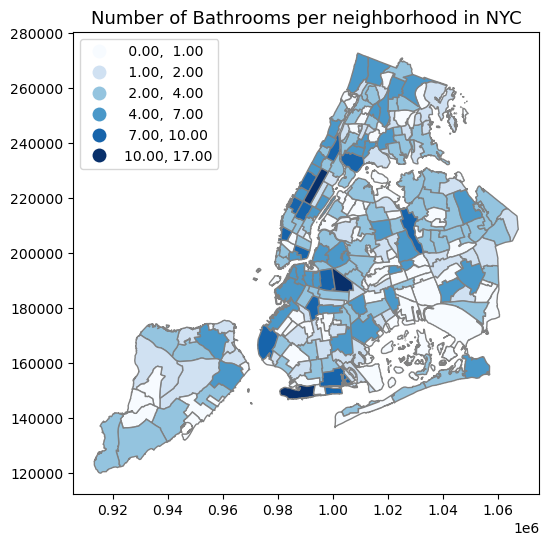

In [18]:
import mapclassify
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Plot with 6 NaturalBreaks classes, with the Blues colormap
NTA_boundaries.plot(column="restroom_count", 
                   scheme="NaturalBreaks",  # use natural breaks (Jenks)
                   k=6,                     # 6 classes
                   cmap="Blues", 
                   legend=True, 
                   ax=ax, 
                   edgecolor="gray",
                   legend_kwds={'loc': 'upper left'})

ax.set_title("Number of Bathrooms per neighborhood in NYC", fontsize=13)

plt.show()

## Spatial Analysis: How many bathrooms are within a 800m radius of each subway station?

In [ ]:
from geopandas import GeoDataFrame

# project to a meter‐based CRS for buffering
stations_m = stations.to_crs(epsg=2263)
restrooms_m = restrooms_clean.to_crs(epsg=2263)

# buffer 800 m
stations_m["buffer"] = stations_m.geometry.buffer(800)

# Drop the geometry column from the original stations_m GeoDataFrame
station_buffers = gpd.GeoDataFrame(
    stations_m[["Stop Name", "GTFS Stop ID", "Borough", "Line"]],  # keep station name, GTFS ID, borough, line, and station ID
    geometry=stations_m["buffer"],  # use the buffer as its geometry
    crs=stations_m.crs
)

# 4) Spatial-join: which restrooms fall within which buffer
joined = gpd.sjoin(
    restrooms_m,        
    station_buffers,    
    how="inner",        # only keep restrooms that land inside some buffer
    op="within"
)

# 5) Group & count by station
counts = (joined.groupby("GTFS Stop ID").size().reset_index(name="restroom_count"))

# Merge counts back onto stations_m 
stations_m = stations_m.merge(counts, on="GTFS Stop ID", how="left")
stations_m["restroom_count"] = stations_m["restroom_count"].fillna(0).astype(int)



In [ ]:
stations_m.head()

In [ ]:
top10_stations = stations_m.sort_values(by="restroom_count", ascending=False).head(10)

# Plot a bar chart
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(top10_stations["Stop Name"], top10_stations["restroom_count"], color="royalblue")
ax.set_title("Top 10 Stations with Most Bathrooms")
ax.set_xlabel("Station")
ax.set_ylabel("Bathroom Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
# Reproject
station_buffers = station_buffers.to_crs(epsg=4326)
stations_wgs     = stations_m.to_crs(epsg=4326)            
restrooms_wgs    = restrooms_clean.to_crs(epsg=4326)       

# 6) plot
fig, ax = plt.subplots(figsize=(8, 6))

# Buffers 
station_buffers.plot(
    ax=ax,
    facecolor="none",         # no interior fill
    edgecolor="gold",
    linewidth=1.5,
    zorder=1,
    label="800 m buffer"
)

# 2) Station points
stations_wgs.plot(
    ax=ax,
    marker="o",
    color="darkblue",
    markersize=5,             # much smaller than 50
    alpha=0.7,
    zorder=2,
    label="Stations"
)

# 3) Restrooms
restrooms_wgs.plot(
    ax=ax,
    marker="o",
    color="red",
    markersize=5,
    alpha=0.8,
    zorder=3,
    label="Restrooms"
)

ax.set_title("NYC Stations + 800 m Buffers + Restrooms")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# custom legend so the polygon handle shows up
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

legend_elems = [
    mpatches.Patch(facecolor="white", edgecolor="gold", label="800 m buffer"),
    Line2D([0],[0], marker='o', color='darkblue', linestyle='', markersize=8, label='Stations'),
    Line2D([0],[0], marker='o', color='red', linestyle='', markersize=6, label='Restrooms'),
]
ax.legend(handles=legend_elems, loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
# Calculate counts
has_restroom = stations_wgs["restroom_count"] > 0
counts = has_restroom.value_counts().sort_index()  # False then True

labels = ["0 Bathrooms within 800 m", "≥1 Bathroom within 800 m"]
sizes = [counts.get(False, 0), counts.get(True, 0)]

# Plot pie chart
fig, ax = plt.subplots(figsize=(4, 4))
ax.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=90)
ax.set_title("Stations by Nearby Restroom Availability (800 m radius)")
ax.axis("equal")
plt.show()

In [ ]:
import seaborn as sns

# Make sure your restrooms are in EPSG:4326
restrooms_wgs = restrooms_m.to_crs(epsg=4326)

# Subset to fully accessible
acc_rest = restrooms_wgs[restrooms_wgs["Accessibility"] == "Fully Accessible"]

# Extract lon/lat
x_acc = acc_rest.geometry.x
y_acc = acc_rest.geometry.y

# Create a single‐panel figure
fig, ax = plt.subplots(figsize=(8, 8))

# Hexbin plot
hb = ax.hexbin(
    x_acc, y_acc,
    gridsize=50,
    cmap="Greens",
    mincnt=1,
    edgecolor="none"
)

# Add a colorbar
cb = fig.colorbar(hb, ax=ax)
cb.set_label("Number of Restrooms in Bin")

# Labels and title
ax.set_title("Hexbin: Fully Accessible Restrooms")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal")

plt.tight_layout()
plt.show()


In [ ]:
stations_wgs.drop(columns=["buffer", "Georeference"], inplace=True)

In [ ]:
stations_wgs.to_file("stations_count.geojson", driver="GeoJSON")

In [ ]:
from geopandas import GeoDataFrame

# Write out to GeoJSON
station_buffers.to_file("stations_buffer.geojson", driver="GeoJSON")


In [ ]:
restrooms_wgs.to_file("restrooms.geojson", driver="GeoJSON")

In [ ]:
from folium.plugins import MarkerCluster

# 1) Base map
m = folium.Map(location=[40.7128, -74.0060], zoom_start=11)

# 2) Buffers
buffer_layer = folium.FeatureGroup(name="800 m Station Buffers", show=False)
folium.GeoJson(
    station_buffers.__geo_interface__,
    style_function=lambda feat: {
        "fillColor": "yellow",
        "color": "red",
        "weight": 1,
        "fillOpacity": 0.2,
    }
).add_to(buffer_layer)
buffer_layer.add_to(m)

# Stations
station_layer = folium.FeatureGroup(name="Subway Stations", show=True)
for _, row in stations_wgs.iterrows():
    folium.CircleMarker(
        [row.geometry.y, row.geometry.x],
        radius=4,
        color="black",
        fill=True,
        fill_color="black",
        fill_opacity=0.8,
        popup=row["Stop Name"],
    ).add_to(station_layer)
station_layer.add_to(m)

# all restrooms (cluster)
all_rest_cluster = MarkerCluster(name="All Restrooms", show=False)
for _, row in restrooms_wgs.iterrows():
    folium.CircleMarker(
        [row.geometry.y, row.geometry.x],
        radius=4,
        color="red",
        fill=True,
        fill_color="red",
        fill_opacity=0.6,
        popup=row.get("Facility Name", "Restroom"),
    ).add_to(all_rest_cluster)
all_rest_cluster.add_to(m)

# fully accessible restrooms (cluster)
acc_rest = restrooms_wgs[restrooms_wgs["Accessibility"] == "Fully Accessible"]
acc_cluster = MarkerCluster(name="Fully Accessible Restrooms", show=True)
for _, row in acc_rest.iterrows():
    folium.CircleMarker(
        [row.geometry.y, row.geometry.x],
        radius=5,
        color="green",
        fill=True,
        fill_color="green",
        fill_opacity=0.8,
        popup=f"{row.get('Facility Name','Restroom')}<br><em>Fully Accessible</em>",
    ).add_to(acc_cluster)
acc_cluster.add_to(m)

# 5) Layer control
folium.LayerControl(collapsed=False).add_to(m)

# 6) Display
m
